In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
    "torch", "torchaudio", "--index-url", "https://download.pytorch.org/whl/cu121",
    "--quiet"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install",
    "tqdm", "scikit-learn", "matplotlib", "seaborn", "--quiet"], check=True)
print("Dependencies Done")

In [ ]:
import os, re, random, time, warnings, math
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
import torchaudio.functional as AF
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print("Imports done")

c:\Users\Dylan\miniconda3\envs\audio\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports done


In [ ]:
DATA_ROOT      = Path("data")
TEST_NOTES_DIR = Path("test_notes")
CHECKPOINT_DIR = Path("checkpoints_v5")
OUTPUT_DIR     = Path("outputs_v5")

N_STRINGS = 6
N_FRETS   = 23  # 0-22

SR = 16000          # back to proven 16kHz
CLIP_DUR = 2.0
CLIP_LEN = int(SR * CLIP_DUR)

BATCH   = 64
EPOCHS  = 100
LR      = 3e-4
WD      = 1e-3
PATIENCE = 15
WORKERS  = 0
SEED     = 42
TTA_RUNS = 9

# Loss weights
W_JOINT  = 0.6
W_STRING = 0.2
W_FRET   = 0.2

OPEN_MIDI = {0:40, 1:45, 2:50, 3:55, 4:59, 5:64}
STR_NAMES = ["E2","A2","D3","G3","B3","E4"]
NOTE_NAMES = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]

print("Config done")

Config done


In [5]:
# ── Position maps ──
POS_LIST = []
POS_TO_IDX = {}
MIDI_TO_POSIDX = defaultdict(list)

for s in range(N_STRINGS):
    for f in range(N_FRETS):
        idx = len(POS_LIST)
        POS_LIST.append((s, f))
        POS_TO_IDX[(s, f)] = idx
        MIDI_TO_POSIDX[OPEN_MIDI[s] + f].append(idx)

N_POS = len(POS_LIST)

# Same-pitch conflict lookup
SAME_PITCH = {}
for midi, idxs in MIDI_TO_POSIDX.items():
    if len(idxs) > 1:
        for i in idxs:
            SAME_PITCH[i] = [j for j in idxs if j != i]

print(f"Positions: {N_POS}  |  With same-pitch conflicts: {len(SAME_PITCH)}")

Positions: 138  |  With same-pitch conflicts: 128


In [6]:
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
CHECKPOINT_DIR.mkdir(exist_ok=True); OUTPUT_DIR.mkdir(exist_ok=True)

DEV = torch.device("cuda" if torch.cuda.is_available() else
                    "mps" if hasattr(torch.backends,'mps') and torch.backends.mps.is_available()
                    else "cpu")
if DEV.type=="cuda": torch.backends.cudnn.benchmark = True
print(f"Device: {DEV}")

Device: cuda


In [7]:
def scan_dataset(root):
    samples = []
    for folder in sorted(root.iterdir()):
        m = re.match(r"string_(\d+)_fret_(\d+)", folder.name)
        if not m: continue
        s, f = int(m.group(1))-1, int(m.group(2))
        pos = POS_TO_IDX[(s, f)]
        for wav in folder.glob("*.wav"):
            samples.append((wav, s, f, pos))
    return samples

all_samples = scan_dataset(DATA_ROOT)
assert len(all_samples) > 0
print(f"Samples: {len(all_samples)}")

Samples: 11802


In [8]:
def pad_or_trim(x, n):
    if x.shape[-1] >= n: return x[..., :n]
    return F.pad(x, (0, n - x.shape[-1]))

print("Caching waveforms...")
WAV = {}
for path, *_ in tqdm(all_samples, unit="f"):
    wav, sr = torchaudio.load(path)
    if wav.shape[0] > 1: wav = wav.mean(0, keepdim=True)
    if sr != SR: wav = AF.resample(wav, sr, SR)
    WAV[str(path)] = pad_or_trim(wav, CLIP_LEN)
print(f"Cached {len(WAV)} ({sum(v.nelement()*4 for v in WAV.values())/1e6:.0f} MB)")

Caching waveforms...


100%|██████████| 11802/11802 [00:54<00:00, 218.37f/s]

Cached 11802 (1511 MB)


## Augmentation (fast, no resample)

In [ ]:
def random_gain(x, lo=0.5, hi=1.5):
    return x * random.uniform(lo, hi)

def add_noise(x, snr_lo=15.0, snr_hi=40.0):
    snr = random.uniform(snr_lo, snr_hi)
    n = torch.randn_like(x)
    sp = x.pow(2).mean().clamp(min=1e-9)
    np_ = n.pow(2).mean().clamp(min=1e-9)
    return x + n * torch.sqrt(sp / (np_ * 10**(snr/10)))

def random_eq(x, sr):
    return AF.equalizer_biquad(x, sr,
        center_freq=random.uniform(200, 5000),
        gain=random.uniform(-6, 6), Q=random.uniform(0.5, 2.0))

def time_shift(x):
    s = random.randint(-CLIP_LEN//8, CLIP_LEN//8)
    if s > 0: x = torch.cat([torch.zeros(1,s), x[:,:-s]], 1)
    elif s < 0: x = torch.cat([x[:,-s:], torch.zeros(1,-s)], 1)
    return x

def spectral_tilt(x, sr):
    return AF.equalizer_biquad(x, sr, 2000.0,
        gain=random.uniform(-4, 4), Q=0.5)

def augment(x, train):
    if not train: return x
    if random.random() < 0.8: x = random_gain(x)
    if random.random() < 0.4: x = random_eq(x, SR)
    if random.random() < 0.3: x = spectral_tilt(x, SR)
    if random.random() < 0.4: x = add_noise(x)
    if random.random() < 0.5: x = time_shift(x)
    pk = x.abs().max()
    if pk > 1e-6: x = x / pk
    return x

def augment_tta(x):
    if random.random() < 0.5: x = random_gain(x, 0.8, 1.2)
    if random.random() < 0.3: x = add_noise(x, 30, 50)
    if random.random() < 0.3:
        s = random.randint(-CLIP_LEN//16, CLIP_LEN//16)
        if s > 0: x = torch.cat([torch.zeros(1,s), x[:,:-s]], 1)
        elif s < 0: x = torch.cat([x[:,-s:], torch.zeros(1,-s)], 1)
    return x

print("Augmentation done")

Augmentation done


## Features — 5 channels

In [ ]:
N_MELS = 128; N_FFT = 2048; HOP = 256; N_CH = 5
ATTACK_LEN = int(SR * 0.15)

_mel  = T.MelSpectrogram(sample_rate=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS)
_db   = T.AmplitudeToDB(top_db=80)
_mfcc = T.MFCC(sample_rate=SR, n_mfcc=20,
               melkwargs={'n_fft':N_FFT,'hop_length':HOP,'n_mels':N_MELS})
_tmask = T.TimeMasking(40)
_fmask = T.FrequencyMasking(16)

def _rsz(t2d, h, w):
    return F.interpolate(t2d[None,None], (h,w), mode='bilinear',
                         align_corners=False)[0,0]

def extract(x, train):
    mel = _db(_mel(x))                                      # (1,128,T)
    Tf = mel.shape[-1]
    harm = F.avg_pool2d(mel[None], (1,9), 1, (0,4))[0]     # (1,128,T)
    delta = F.pad(mel[...,1:]-mel[...,:-1], (1,0))          # (1,128,T)
    mfcc_r = _rsz(_mfcc(x).squeeze(0), N_MELS, Tf)[None]   # (1,128,T)
    att = _db(_mel(x[...,:ATTACK_LEN]))
    att_r = _rsz(att.squeeze(0), N_MELS, Tf)[None]          # (1,128,T)

    feat = torch.cat([mel, harm, delta, mfcc_r, att_r], 0)  # (5,128,T)
    for c in range(N_CH):
        ch = feat[c]; feat[c] = (ch - ch.mean()) / (ch.std() + 1e-6)
    if train:
        if random.random() < 0.5: feat = _tmask(feat)
        if random.random() < 0.5: feat = _fmask(feat)
    return feat

print(f"Features: {extract(torch.randn(1,CLIP_LEN), False).shape} done")

Features: torch.Size([5, 128, 126]) done


In [ ]:
class GuitarDS(Dataset):
    def __init__(self, samples, train):
        self.samples = samples
        self.train = train
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, s, f, pos = self.samples[idx]
        x = WAV[str(path)].clone()
        x = augment(x, self.train)
        return extract(x, self.train), s, f, pos

print("Dataset done")

Dataset done


In [ ]:
labels = [f"{s}_{f}" for _,s,f,_ in all_samples]
tv, test_s = train_test_split(all_samples, test_size=0.10,
                               stratify=labels, random_state=SEED)
labels_tv = [f"{s}_{f}" for _,s,f,_ in tv]
train_s, val_s = train_test_split(tv, test_size=0.111,
                                   stratify=labels_tv, random_state=SEED)
print(f"Train:{len(train_s)} Val:{len(val_s)} Test:{len(test_s)}")

# Upweight positions with same-pitch conflicts
combo_cnt = defaultdict(int)
for _,s,f,_ in train_s: combo_cnt[(s,f)] += 1
sw = []
for _,s,f,pos in train_s:
    w = 1.0 / combo_cnt[(s,f)]
    if pos in SAME_PITCH: w *= 1.5
    sw.append(w)
sampler = WeightedRandomSampler(sw, len(train_s), replacement=True)

pin = DEV.type=="cuda"
train_dl = DataLoader(GuitarDS(train_s, True), batch_size=BATCH,
                      sampler=sampler, num_workers=WORKERS, pin_memory=pin)
val_dl = DataLoader(GuitarDS(val_s, False), batch_size=BATCH,
                    shuffle=False, num_workers=WORKERS, pin_memory=pin)
test_dl = DataLoader(GuitarDS(test_s, False), batch_size=BATCH,
                     shuffle=False, num_workers=WORKERS, pin_memory=pin)
print("Loaders done")

Train:9442 Val:1179 Test:1181
Loaders done


## Model — Joint Position Head + Auxiliary Heads



In [ ]:
class ResBlock(nn.Module):
    def __init__(self, ch, drop=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch,ch,3,padding=1,bias=False), nn.BatchNorm2d(ch),
            nn.GELU(), nn.Dropout2d(drop),
            nn.Conv2d(ch,ch,3,padding=1,bias=False), nn.BatchNorm2d(ch))
        self.act = nn.GELU()
    def forward(self, x): return self.act(x + self.block(x))


class GuitarNetV5(nn.Module):
    def __init__(self, n_pos=138, n_str=6, n_fret=23, in_ch=5, drop=0.3):
        super().__init__()
        # v1's proven backbone, just 5 input channels
        self.backbone = nn.Sequential(
            nn.Conv2d(in_ch,32,3,padding=1,bias=False), nn.BatchNorm2d(32), nn.GELU(),
            ResBlock(32), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1,bias=False), nn.BatchNorm2d(64), nn.GELU(),
            ResBlock(64), ResBlock(64), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1,bias=False), nn.BatchNorm2d(128), nn.GELU(),
            ResBlock(128), ResBlock(128), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1,bias=False), nn.BatchNorm2d(256), nn.GELU(),
            ResBlock(256), nn.AdaptiveAvgPool2d((4,4)),
        )
        self.flatten = nn.Flatten()
        self.shared = nn.Sequential(
            nn.Linear(256*4*4, 512), nn.GELU(), nn.Dropout(drop),
        )

        # PRIMARY: joint position head
        self.pos_head = nn.Sequential(
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(drop/2),
            nn.Linear(256, n_pos),
        )
        # AUXILIARY: string & fret heads for regularisation
        self.str_head = nn.Sequential(
            nn.Linear(512, 128), nn.GELU(), nn.Dropout(drop/3),
            nn.Linear(128, n_str),
        )
        self.fret_head = nn.Sequential(
            nn.Linear(512, 128), nn.GELU(), nn.Dropout(drop/3),
            nn.Linear(128, n_fret),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        emb = self.shared(self.flatten(self.backbone(x)))
        return self.pos_head(emb), self.str_head(emb), self.fret_head(emb)


model = GuitarNetV5(n_pos=N_POS, in_ch=N_CH).to(DEV)
print(f"GuitarNet v5 Done  |  {sum(p.numel() for p in model.parameters() if p.requires_grad):,} params")

GuitarNet v5 done  |  4,727,047 params


In [ ]:
pos_crit  = nn.CrossEntropyLoss(label_smoothing=0.05)
str_crit  = nn.CrossEntropyLoss(label_smoothing=0.1)
fret_crit = nn.CrossEntropyLoss(label_smoothing=0.1)

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=20, T_mult=2, eta_min=1e-6)
scaler = torch.amp.GradScaler('cuda', enabled=DEV.type=='cuda')

print(f"Loss Done  weights: joint={W_JOINT} str={W_STRING} fret={W_FRET}")

Loss done  weights: joint=0.6 str=0.2 fret=0.2


## Training

In [15]:
def run_epoch(dl, train, desc=""):
    model.train() if train else model.eval()
    tot = pos_ok = str_ok = fret_ok = both_ok = n = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    pbar = tqdm(dl, desc=desc, leave=False, unit="b")

    with ctx:
        for feat, s_lbl, f_lbl, pos_lbl in pbar:
            feat    = feat.to(DEV, non_blocking=True)
            s_lbl   = s_lbl.to(DEV, non_blocking=True)
            f_lbl   = f_lbl.to(DEV, non_blocking=True)
            pos_lbl = pos_lbl.to(DEV, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=DEV.type=='cuda'):
                p_log, s_log, f_log = model(feat)
                loss = (W_JOINT  * pos_crit(p_log, pos_lbl) +
                        W_STRING * str_crit(s_log, s_lbl) +
                        W_FRET   * fret_crit(f_log, f_lbl))

            if train:
                opt.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt); scaler.update()

            bs = feat.size(0)
            tot += loss.item() * bs

            # Decode joint prediction
            pred_pos = p_log.argmax(1)
            pred_s = torch.tensor([POS_LIST[p.item()][0] for p in pred_pos],
                                  device=DEV)
            pred_f = torch.tensor([POS_LIST[p.item()][1] for p in pred_pos],
                                  device=DEV)

            pos_ok  += (pred_pos == pos_lbl).sum().item()
            str_ok  += (pred_s == s_lbl).sum().item()
            fret_ok += (pred_f == f_lbl).sum().item()
            both_ok += ((pred_s == s_lbl) & (pred_f == f_lbl)).sum().item()
            n += bs

            pbar.set_postfix(l=f"{tot/n:.3f}", j=f"{pos_ok/n:.0%}",
                             s=f"{str_ok/n:.0%}")

    return {"loss":tot/n, "pos_acc":pos_ok/n, "str_acc":str_ok/n,
            "fret_acc":fret_ok/n, "combined":both_ok/n}

In [ ]:
hist = {"tr":[], "va":[]}
best = 0.0; wait = 0

for ep in tqdm(range(1, EPOCHS+1), desc="Epochs", unit="ep"):
    t0 = time.time()
    tr = run_epoch(train_dl, True, f"Tr{ep}")
    va = run_epoch(val_dl, False, f"Va{ep}")
    sched.step()
    hist["tr"].append(tr); hist["va"].append(va)

    imp = va["pos_acc"] > best
    if imp:
        best = va["pos_acc"]
        torch.save(model.state_dict(), CHECKPOINT_DIR/"best_v5.pt")
        wait = 0
    else: wait += 1

    print(f"Ep{ep:3d} [{time.time()-t0:.0f}s] "
          f"Tr j={tr['pos_acc']:.1%} s={tr['str_acc']:.1%} | "
          f"Va j={va['pos_acc']:.1%} s={va['str_acc']:.1%} "
          f"{'Done' if imp else ''}")

    if wait >= PATIENCE:
        print(f"Early stop ep {ep}"); break

print(f"\nBest val pos acc: {best:.2%}")

Epochs:   1%|          | 1/100 [01:32<2:33:17, 92.90s/ep]

Ep  1 [93s] Tr j=2.6% s=31.8% | Va j=6.6% s=43.1% done


Epochs:   2%|▏         | 2/100 [03:02<2:28:14, 90.76s/ep]

Ep  2 [89s] Tr j=8.7% s=44.8% | Va j=16.7% s=55.0% done


Epochs:   3%|▎         | 3/100 [04:30<2:25:11, 89.81s/ep]

...

Ep 60 [91s] Tr j=97.1% s=97.5% | Va j=99.8% s=99.8% 


Epochs:  61%|██████    | 61/100 [1:31:47<59:52, 92.13s/ep]  

Ep 61 [92s] Tr j=95.0% s=95.6% | Va j=99.2% s=99.2% 


Epochs:  61%|██████    | 61/100 [1:33:18<59:39, 91.78s/ep]

Ep 62 [91s] Tr j=94.5% s=95.3% | Va j=99.2% s=99.5% 
Early stop ep 62

Best val pos acc: 99.83%


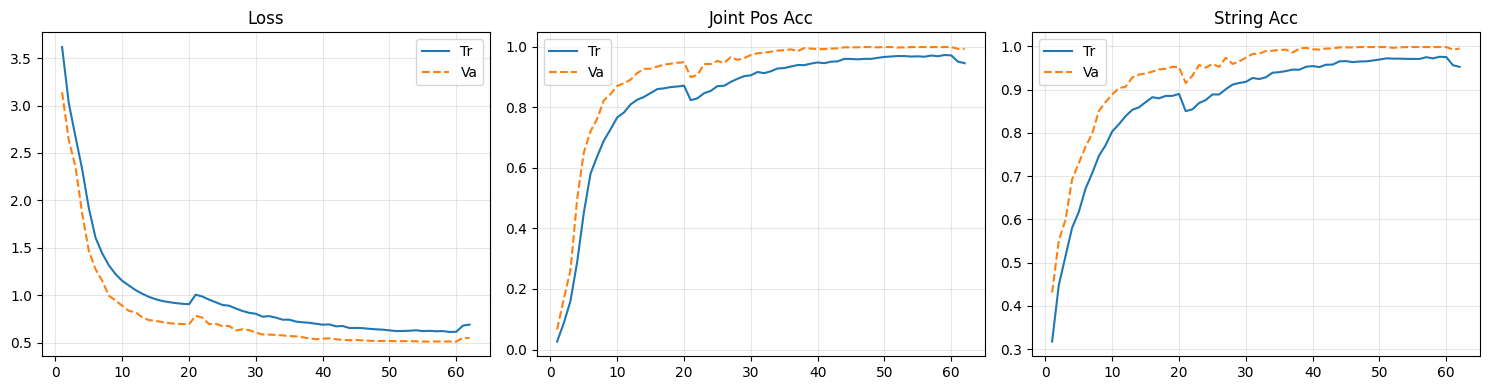

In [17]:
er = range(1, len(hist["tr"])+1)
fig, ax = plt.subplots(1,3,figsize=(15,4))
for a,k,t in zip(ax, ["loss","pos_acc","str_acc"], ["Loss","Joint Pos Acc","String Acc"]):
    a.plot(er,[m[k] for m in hist["tr"]], label="Tr")
    a.plot(er,[m[k] for m in hist["va"]], label="Va", ls="--")
    a.set_title(t); a.legend(); a.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"curves_v5.png", dpi=150); plt.show()

In [18]:
model.load_state_dict(torch.load(CHECKPOINT_DIR/"best_v5.pt",
                                  map_location=DEV, weights_only=True))
tm = run_epoch(test_dl, False, "Test")
print(f"\nTest: joint={tm['pos_acc']:.2%} str={tm['str_acc']:.2%} "
      f"fret={tm['fret_acc']:.2%} combined={tm['combined']:.2%}")


Test: joint=99.41% str=99.41% fret=99.58% combined=99.41%


## Predict (TTA only, no priors)

In [ ]:
def predict(wav_path, tta=True, verbose=True):
    model.eval()
    wav, sr = torchaudio.load(wav_path)
    if wav.shape[0]>1: wav = wav.mean(0, keepdim=True)
    if sr != SR: wav = AF.resample(wav, sr, SR)
    wav = pad_or_trim(wav, CLIP_LEN)
    pk = wav.abs().max()
    if pk > 1e-6: wav = wav / pk

    runs = TTA_RUNS if tta else 1
    logsum = None
    with torch.no_grad():
        for i in range(runs):
            x = wav.clone() if i==0 else augment_tta(wav.clone())
            feat = extract(x, False).unsqueeze(0).to(DEV)
            with torch.amp.autocast('cuda', enabled=DEV.type=='cuda'):
                p_log, _, _ = model(feat)
            logsum = p_log if logsum is None else logsum + p_log

    probs = F.softmax(logsum / runs, 1).squeeze(0)
    pi = probs.argmax().item()
    s, f = POS_LIST[pi]
    conf = probs[pi].item()
    midi = OPEN_MIDI[s] + f
    note = NOTE_NAMES[midi % 12]

    if verbose:
        top3 = probs.topk(3)
        alts = ", ".join([f"s{POS_LIST[j.item()][0]+1}f{POS_LIST[j.item()][1]}({v:.0%})"
                          for v,j in zip(top3.values, top3.indices)])
        print(f"  s{s+1}f{f} ({STR_NAMES[s]}) {note} [{conf:.0%}]  top3: {alts}")
    return s, f

print("predict() done")

predict() done


In [ ]:
torch.save({'state':model.state_dict(), 'pos_list':POS_LIST,
            'config':{'sr':SR,'n_ch':N_CH,'n_pos':N_POS}},
           OUTPUT_DIR/"model_v5.pt")
print("Saved done")